# Dictionary  usagae 


In [1]:
  # in hashmap  lookup operation is o(1) and insertiona and deletion is also o(1) on average 
def get_hash(key):
    h=0
    for char in key: 
        h+= ord(char)
    return h %100



In [2]:
get_hash('march 28')

61

In [ ]:
class HashTable:
    def __init__ (self):
        self.MAX = 100
        self.arr = [ None for i in range(self.MAX)] # llist comprehesnion

    def get_hash(self,key):
        h = 0
        for char in key:
            h+= ord(char)

            return h% self.Max 
    def add (self,key , value)        :
        h = self.get_hash(key)
        self.arr[h] = val
        
        

In [ ]:
# createa  objct of class in python
t = HashTable()
t.get_hash('march 6')

# Design a HashMap without using any built-in hash table libraries.
https://leetcode.ca/2017-11-05-706-Design-HashMap/

### solution: 
A straightforward approach to implement a hash map is to use chaining with a list of buckets, where each bucket is a list (or linked list) of tuples representing key-value pairs.

- Since all keys and values are in the range of [0, 1000000], create an array with length 1000001, which has int type. Initially, all the elements in the array are -1.

- For the put function, set the value at index key in the array to be value.

- For the remove function, set the value at index key in the array to be -1.

- For the get function, simply return the element at index key.

Some of the questions which can be asked to the interviewer before implementing the solution:

1. For simplicity, are the keys integers only?
2. For collision resolution, can we use chaining?
3. Do3 we have to worry about load factors?
4. Can we assume inputs are valid or do we have to validate them?
5. Can we assume this fits memory?
## Open addressing with linear probing
There are other ways to implement a HashMap beyond the chaining method with buckets. One alternative approach is to use open addressing with linear probing for collision resolution. In this method, when a collision occurs (i.e., two keys hash to the same index), the algorithm probes subsequent indices in the array (wrapping around to the beginning if necessary) until an empty slot (or the key itself, if already present) is found.

### Key Differences and Features:
- Initialization (__init__): The HashMap is initialized with a fixed-size array (self.data) that stores key-value pairs directly. A special marker (self.DELETED) is used to indicate deleted entries, which is necessary for linear probing to function correctly.

- Linear Probing in put: To insert a new key-value pair, the method computes the index for the key using the _hash function. If the computed index is occupied (by a different key), it linearly probes subsequent indices until an empty slot or the key itself is found.

- Retrieving Values (get): To retrieve a value, the _find helper method is used to locate the key in the array. If found, it returns the associated value; otherwise, -1 is returned.

- Removing Entries (remove): To remove a key-value pair, the _find method locates the key, and its slot is marked as deleted using the self.DELETED marker. This allows linear probing to continue working correctly for other keys.

- Finding Entries (_find): A helper method that attempts to find the slot containing the specified key, taking into account linear probing and deleted entries. It returns both the index and a boolean indicating whether the key was found.

### Advantages and Considerations:
- Space Efficiency: This approach tends to be more space-efficient compared to chaining, especially when the load factor is low to moderate.
- Performance: While open addressing with linear probing can offer good performance for lookups, inserts, and deletions, it may suffer from clustering effects, where consecutive slots become filled, leading to longer probe sequences. Careful management of the load factor and capacity is crucial.
- Resizing: To maintain efficient operations, the capacity of the array may need to be increased (and all keys rehashed) when the load factor gets too high. This resizing logic is not included in the above implementation but would be necessary for a production-level HashMap to ensure performance does not degrade with many entries.

In [ ]:
class MyHashMap:
    def __init__(self):
        self.data = [-1] * 1000001

    def put(self, key: int, value: int) -> None:
        self.data[key] = value

    def get(self, key: int) -> int:
        return self.data[key]

    def remove(self, key: int) -> None:
        self.data[key] = -1


# Your MyHashMap object will be instantiated and called as such:
# obj = MyHashMap()
# obj.put(key,value)
# param_2 = obj.get(key)
# obj.remove(key)

#############

class MyHashMap: # hash to bucket
    def __init__(self):
        """
        Initialize your data structure here.
        """
        self.size = 1000
        self.buckets = [[] for _ in range(self.size)]

    def _hash(self, key: int) -> int:
        """
        Generate a hash for a given key.
        """
        return key % self.size

    def put(self, key: int, value: int) -> None:
        """
        Value will always be non-negative.
        """
        hash_key = self._hash(key)
        for i, (k, v) in enumerate(self.buckets[hash_key]):
            if k == key:
                self.buckets[hash_key][i] = (key, value)
                return
        self.buckets[hash_key].append((key, value))

    def get(self, key: int) -> int:
        """
        Returns the value to which the specified key is mapped, or -1 if this map contains no mapping for the key.
        """
        hash_key = self._hash(key)
        for k, v in self.buckets[hash_key]:
            if k == key:
                return v
        return -1

    def remove(self, key: int) -> None:
        """
        Removes the mapping of the specified value key if this map contains a mapping for the key.
        """
        hash_key = self._hash(key)
        for i, (k, v) in enumerate(self.buckets[hash_key]):
            if k == key:
                del self.buckets[hash_key][i]
                return

###############
# 2nd approach
class MyHashMap: # open addressing with linear probing
    def __init__(self):
        self.capacity = 10000
        self.data = [None] * self.capacity
        self.DELETED = (None, None)  # Marker for deleted entries

    def _hash(self, key):
        return key % self.capacity

    def put(self, key: int, value: int) -> None:
        idx = self._hash(key)
        while self.data[idx] not in (None, self.DELETED, key):
            idx = (idx + 1) % self.capacity
        self.data[idx] = (key, value)

    def get(self, key: int) -> int:
        idx, found_key = self._find(key)
        if found_key:
            return self.data[idx][1]
        return -1

    def remove(self, key: int) -> None:
        idx, found_key = self._find(key)
        if found_key:
            self.data[idx] = self.DELETED

    def _find(self, key):
        original_idx = idx = self._hash(key)
        while self.data[idx] is not None:
            if self.data[idx] != self.DELETED and self.data[idx][0] == key:
                return idx, True
            idx = (idx + 1) % self.capacity
            if idx == original_idx:  # Came full circle
                break
        return original_idx, False






## Special Case: When Hash Map Complexity Becomes O(n)

While hash maps are designed for O(1) average-case performance, there are specific scenarios where operations degrade to O(n), where `n` is the number of elements in the hash map. Let’s discuss this case clearly for an interviewer.

### Scenario: High Collision Rate Due to Poor Hash Function

The primary reason a hash map’s complexity becomes O(n) is a **poor hash function** that causes many keys to map to the same index, leading to excessive collisions.

- **What Happens**:
  - If the hash function consistently maps different keys to the same index (or a small subset of indices), the hash map behaves like a single linked list (in separate chaining) or requires many probes (in open addressing).
  - For example, if all `n` keys hash to the same index, operations like lookup, insertion, or deletion require traversing all `n` elements in that bucket or probing many slots, resulting in O(n) time complexity.

- **Why It Happens**:
  - **Poor Hash Function Design**: A hash function that doesn’t distribute keys uniformly. For instance, if the hash function for strings only considers the first character, keys like "apple", "ant", and "avocado" might all map to the same index.
  - **Adversarial Inputs**: In rare cases, an attacker could craft inputs that exploit the hash function’s weaknesses, causing intentional collisions (e.g., in a denial-of-service attack). Python mitigates this by randomizing hash seeds per session since Python 3.3, but a poorly designed custom hash function could still cause issues.
  - **Degenerate Input Patterns**: If keys have a pattern that aligns poorly with the hash function (e.g., all keys are multiples of a number that maps to the same index modulo the table size), collisions increase.



### Other Contributing Factors

1. **High Load Factor Without Resizing**:
   - If the hash map’s array is not resized when the load factor becomes too high (e.g., too many elements relative to the number of buckets), collisions increase.
   - In Python’s `dict`, automatic resizing prevents this, but in a custom implementation with a fixed-size array, a high load factor could lead to many collisions, degrading performance to O(n) for operations.

2. **Edge Case in Open Addressing**:
   - In open addressing (like Python’s `dict`), collisions are resolved by probing other slots. If the table is nearly full or the probing sequence is poorly designed, finding an empty slot or a key can require checking many slots, approaching O(n) in the worst case.
   - Example: If the table is 90% full and the probe sequence clusters keys, lookup may need to scan a large portion of the table.

### Interview Talking Points

To explain this to an interviewer, I’d structure my response as follows:

1. **Acknowledge the Average Case**:
   - “Typically, a hash map provides O(1) average-case time complexity for lookups, insertions, and deletions due to a good hash function that distributes keys evenly and a reasonable load factor.”

2. **Introduce the Worst Case**:
   - “However, in the worst case, the time complexity can degrade to O(n) if the hash function causes many collisions, effectively turning the hash map into a linear search over many elements.”

3. **Explain the Cause**:
   - “This happens when the hash function maps most or all keys to the same index, leading to a single bucket with many elements (in separate chaining) or excessive probing (in open addressing). For example, a poorly designed hash function that always returns the same index would cause all operations to scan through all `n` elements.”

4. **Provide Context**:
   - “In practice, Python’s `dict` mitigates this with a robust hash function and automatic resizing to keep the load factor low. But in a custom implementation or with adversarial inputs, we could see O(n) performance.”

5. **Connect to Real-World Implications**:
   - “This is why hash function design is critical. For instance, in competitive programming or system design, we need to ensure the hash function distributes keys well to avoid performance degradation. Python’s randomization of hash seeds also helps prevent attacks that exploit collisions.”

6. **Relate to Constraints**:
   - “In problems like the sliding window maximum (which we discussed earlier), we used a deque instead of a hash map because the problem required maintaining a maximum in a window, and a hash map wouldn’t help due to its unordered nature and potential collision issues for custom use cases.”

### Mitigation Strategies

To avoid O(n) complexity in hash maps:
- **Use a Good Hash Function**: Ensure the hash function distributes keys uniformly. Python’s `hash()` function is designed for this.
- **Dynamic Resizing**: Resize the hash table (e.g., double its size) when the load factor exceeds a threshold (Python does this automatically).
- **Handle Collisions Effectively**: Use efficient collision resolution (e.g., Python’s open addressing with quadratic probing).
- **Test Edge Cases**: In competitive programming, test your hash map with inputs that could cause collisions (e.g., similar keys).
- **Consider Alternatives**: For problems sensitive to worst-case performance (e.g., real-time systems), use balanced trees (O(log n) 



# Binary tree and search tree

1. left node has smaller value than right node
2. always we have two child node or one 

### how to create a node
it contains three thing
1. left part : connect with further node
2. data 
3. right part connect with further node

In [2]:
class Node:
    def __init__ (self, value):
        self.left = None 
        self.data = value 
        self.right= None


###  for solving any question check:
- how node class is delcared
- how tree class is declared , 
- which traversal method is used for printing the tree


## how to make it tree
- how to create a tree 
- how to insert a node
- how to display the node value 
- how to seacrh , delete element
- how to find hieght of tree


In [4]:
class Tree:
    def createNode(self,data):
        return Node(data) # we inherit the node class here 
        #self.left = None 
        #self.right = None 
        #self.data = value

        # how to make it binary tree => left smaller ,right bigger values
    def insert (self, node, data):
        if node is None:
            return self.createNode(data)

        elif data< node.data:
            node.left = self.insert(node.left, data)
        else:
            node.right = self.insert(node.right,data) 
        return node 
        
# now for printing the tree we need to traverse it by any method
    def traverse_Inorder(self,root):
        if root is not None:
            self.traverse_Inorder(root.left)
            print(root.data, '->', end="")
            self.traverse_Inorder(root.right)
            # if we need to retrun a list we can append the node.data to list
           
# if we need to secure our root or any variable  so we save it in temp variable 


# driver Code
tree = Tree()
root = tree.createNode(5)

tree.insert(root,2)
tree.insert(root,10)
tree.insert(root,7)
tree.insert(root,15)

tree.insert(root,12)
tree.insert(root,20)
tree.insert(root,30)
tree.insert(root,6)
tree.insert(root,8)
print('Inorder_Traversal : ---->')
tree.traverse_Inorder(root)


Inorder_Traversal : ---->
2 ->5 ->6 ->7 ->8 ->10 ->12 ->15 ->20 ->30 ->

### tree

        5
    2      10
        7.    15
    6    8  12   20
                    30

## printing the value
1. inorder : L Root,R
2. preordr: Root, L,R
3. postorder : L, R, root

## Hacker rank question :
https://www.hackerrank.com/challenges/binary-search-tree-insertion/problem


# insertion code


In [5]:
def insert(self,val):
    if self.root is None:
        self.root = Node(val)
        return
    root = self.root
    while 1: # one
        if val<root.info:
            if root.left is not None:
                root = root.left 
            else: 
                root.left = Node(val)
                break
        elif val>= root.info:
            if root.right is not None:
                root= root.right
            else: 
                root.right = Node(val)
                break 



# Inorder Traversal 
## L, root, R

In [16]:
res = []
def inOrder(root):
    if root is not None:
        inOrder(root.left)
        print(root.value, end= ' ')
        inOrder(root.right)
    

# print res 

#or full code
class Solution:
    def inorderTraversal(root) :
        if root==None:
            return []
            
         
        return inorderTraversal(root.left) +[root.data]+inorderTraversal(root.right) 
Solution.inorderTraversal(root)

NameError: name 'inorderTraversal' is not defined

# pre order traversal 
## root, L, R


In [ ]:
def preOrder(root):
    if root is not None:
        print(root.data)
        preOrder(root.left)
        preOrder(root.right) 

# full code 
class Solution:
    def preorderTraversal(self, root):
        res=[]
        def preorder(root):
            if root:
                res.append(root.val)
                preorder(root.left)
                preorder(root.right)
        preorder(root,res)
        return res

# postorder
L,R, root

In [ ]:
def postOrder(root):
    if root is not None:
        postOrder(root.left)
        postOrder(root.right)
        print(root.data)

# full code 
class Solution:
    def postorderTraversal(self, root):
        res=[]
        def postorder(root):
            if root:
             
                postorder(root.left)
                postorder(root.right)
                res.append(root.val)
        postorder(root)
        return res

In [ ]:
# other way of traversal
def traverse(self, root):
        # we need to traverse the tree and we can use any methodf 
        def preorder(root):
            if root: 
                return (root.val, preorder(root.left), preorder(root.right))
        # in last we just check that the traversal is equal or not 
        return preorder(root)



# Height of tree


#### for height change maxDepth = height

In [11]:
def maxDepth(root): 
    if root is None:
        return 0  # if not root then obviously it is 0
    return max(maxDepth(root.left), maxDepth(root.right))+1
        # and for the height we check max(left , right ) of the tree
maxDepth(root)

5

# Levelorder 
## means leavel wise traversal


- we require que data structure and  list 
    - queue => for storing the nodes of root
    - list is for storing the root 
- next iteration:
    - for each iteration we we take a new list and add level values in it 
    - take the next que element and check its node element and put in queue  and put that root in list 
- do same for the next iterations 
- append all the lists ofeach levels to one list 
return that list 
- example 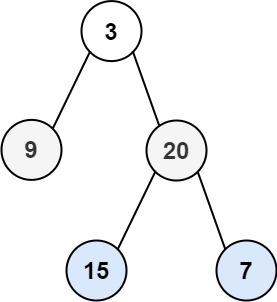

    root = [3,9,20,null,null,15,7]
- solution = [[3],[9,20],[15,7]]

- 1st step declare a queue and a list ;  we put root 3 in queue  then we put its nodes in que, and append 3 to the list.
- then 2nd step we take next element in queue and put its node in queue, and append that in the list 
- repaeat this step till we have element in the queues , when queue is empty ; we return the list 


### tree

        5
    2      10
        7.    15
    6    8  12   20
                    30

In [ ]:
def levelOrder(root):
    if not root:
        return []
    
    q = []
    q.append(root)
    while len (q)!= 0:
        root = q.pop(0)
        print(root.data)
        if root.left is not None:
            q.append(root.left)
        if root.right is not None:
            q.append(root.left)
    return q

#full code according to questions: 

# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
from collections import deque
class Solution:
    def levelOrder(root) :
 # first decleare the queue and main list 
        lis=[]
        q= deque()
        q.append(root) # add the root to the queue
        while q: 
            level_values = [] # make list for each level valeues
            for _ in range(len(q)):  # now traverse the queue 
                curr_node = q.popleft()# take element from the queue and checkits nodes
                if curr_node: # add value of current node to list and check its nodes
                    level_values.append(curr_node.data)
                    q.append(curr_node.left)# if left, right nodes then add to the queue 
                    q.append(curr_node.right)
            if level_values:  # check if some entries in the level_values and append it to the main list 
                lis.append(level_values)
        return lis       
        

# when fucntion is inside a class use this method   
Solution.levelOrder(root)
        

[[5], [2, 10], [7, 15], [6, 8, 12, 20], [30]]

### tree

        5
    2      10
        7.    15
    6    8  12   20
                    30

# top view of tree 
- print only the left value of left nodes, root, right values of right nodes

### we use level order logic 
### queue and dictionary for printing the output 
- queue use as level order logic  to taking the left and right values of nodes 
- dictionary use for the horizontal distance hdis ==> left move = -1 ; right move = +1
- key = variable => 0,1,3 ; value => node data a,b,x
- first put value of root with hdis in queue then pop it 
- check if the hdis is in dict() or not , it not then add 
- check left and right of popped element
- main target is emptying our queue
- in dictionary we dont put same value twice 
- in last print the value of the dictionary

In [ ]:
from collections import deque



def top_view(root):
    if not root:
        return []

    # Dictionary to store first node at each horizontal distance just once
    hdis_map = {}
    # Queue stores (node, horizontal_distance)
    q = deque([(root, 0)])
    
    while q:
        node, hdis = q.popleft() # 2 element in the ques at one index
        # Store the first node encountered at this HD
        if hdis not in hdis_map:
            hdis_map[hdis] = node.data
        # Add children with updated HD
        if node.left:
            q.append((node.left, hdis - 1))
        if node.right:
            q.append((node.right, hdis + 1))
    # Return values sorted by horizontal distance (left to right)
    return [hdis_map[i] for i in sorted(hdis_map.keys())]   

top_view(root)

[2, 5, 10, 15, 20, 30]

Question:

Input: root = [1,2,3,4,null,null,null,5]

Output: [1,3,4,5]

Explanation:
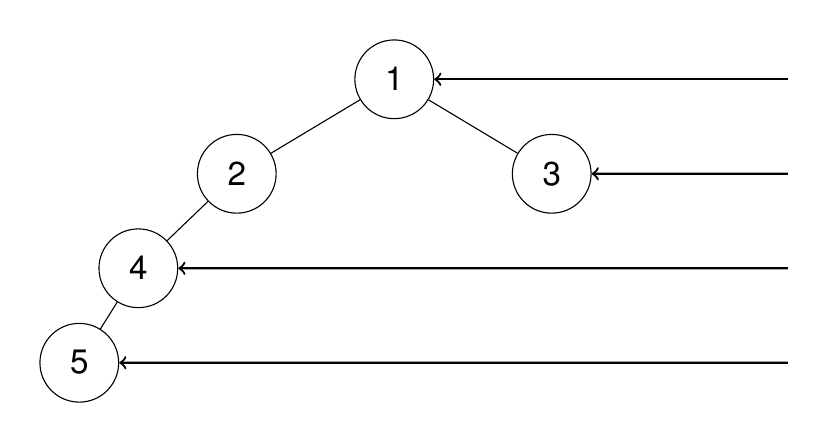


- approach 1:
    - Compute the right view of both right and left left subtree, then combine them. For very unbalanced trees, this can be O(n^2), though.
    

In [ ]:
# right side view of the tree :
def rightSideView(self, root):
    if not root:
        return []
    right = self.rightSideView(root.right)
    left = self.rightSideView(root.left)
    return [root.val] + right + left[len(right):]



In [ ]:
# or 
class Solution:
    def rightSideView(self, root) :

        res = [] # use level order traversal and use 2 datastructure , 
        # level order => que, list 
        if not root:
            return res
        queue = deque([root])
        while queue:
            n = len(queue)
            for i in range(n):
                curr = queue.popleft() # we pop the root and 
                # append it to the list if list is exist
                if i == n - 1:  # we only choosing the right side value 
                    res.append(curr.val)
                if curr.left: # check or the nodes of root and add then to queue
                    queue.append(curr.left)
                if curr.right:
                    queue.append(curr.right)
        return res
        

# Check the treem is binary tree or not
1. check left part< root < right part 
2. check at most 2 branches means 0or 1 or 2 branches


# Using Inorder Traversal - O(n) Time and O(h) Space

- The idea is to use inorder traversal of a binary search tree, in which the output values are sorted in ascending order. After generating the inorder traversal of the given binary tree, we can check if the values are sorted or not.

- Note: We can avoid the use of an Auxiliary Array. While doing In-Order traversal, we can keep track of previously visited value. If the value of the currently visited node is less than the previous value, then the tree is not BST.

In [ ]:
# Python program to check if a tree is BST using Inorder Traversal

class Node:
    def __init__(self, value):
        self.data = value
        self.left = None
        self.right = None

# Recursive Function for inorder traversal
def inorder(root, prev):
    if root is None:
        return True

    # Recursively check the left subtree
    if not inorder(root.left, prev):
        return False

    # Check the current node value against the previous value
    if prev[0] >= root.data:
        return False

    # Update the previous value to the current node's value
    prev[0] = root.data

    # Recursively check the right subtree
    return inorder(root.right, prev)

# Function to check if the tree is a valid BST
def isBST(root):
    prev = [float('-inf')]
    return inorder(root, prev)

if __name__ == "__main__":
  
    # Create a sample binary tree
    #     10
    #    /  \
    #   5    20
    #        / \
    #       9   25

    root = Node(10)
    root.left = Node(5)
    root.right = Node(20)
    root.right.left = Node(9)
    root.right.right = Node(25)

    if isBST(root):
        print("True")
    else:
        print("False")


- Time Complexity: O(n), where n is the number of nodes, as each node is visited once in inorder traversal.
- Auxiliary Space: O(h), where h is the height of the tree, due to recursive calls (worst case O(n) for a skewed tree, O(log n) for a balanced tree).

# Using Morris Traversal - O(n) Time and O(1) Space

- The idea is to use Morris Traversal for checking if a binary tree is a Binary Search Tree (BST) without using extra space for storing the inorder traversal.

Follow the steps below to solve the problem:

1. Start with the root node and traverse the tree while maintaining a pointer to the current node.
2. For each node, find its inorder predecessor (the rightmost node in its left subtree). Use this node to temporarily link back to the current node.
3. If the left child exists, create a temporary thread from the inorder predecessor to the current node.
4. If the left child does not exist, process the current node's data and move to its right child.
5. Once you visit the current node, restore the tree by removing the temporary thread. Check the inorder property and proceed to the right child.
6. C6ompare the current node’s value with the previously visited node’s value.
7. Continue this process until all nodes are visited. If all nodes satisfy the BST property, then the tree is a BST.

In [ ]:
# Python program to check if a tree is BST using Morris Traversal

class Node:
    def __init__(self, value):
        self.data = value
        self.left = None
        self.right = None

# Function to check if the binary tree is a 
# BST using Morris Traversal
def isBST(root):
    curr = root
    prevValue = float('-inf') 

    while curr:
        if curr.left is None:
          
            # Process curr node
            if curr.data <= prevValue: 
              
                # Not in ascending order
                return False
            prevValue = curr.data
            curr = curr.right
        else:
          
            # Find the inorder predecessor of curr
            pre = curr.left
            while pre.right and pre.right != curr:
                pre = pre.right

            if pre.right is None:
              
                # Create a temporary thread to the curr node
                pre.right = curr
                curr = curr.left
            else:
              
                # Remove the temporary thread
                pre.right = None

                # Process the curr node
                if curr.data <= prevValue:
                  
                    # Not in ascending order
                    return False
                prevValue = curr.data
                curr = curr.right

    return True

if __name__ == "__main__":
  
    # Create a sample binary tree
    #     10
    #    /  \
    #   5    20
    #        / \
    #       9   25

    root = Node(10)
    root.left = Node(5)
    root.right = Node(20)
    root.right.left = Node(9)
    root.right.right = Node(25)

    if isBST(root):
        print("True")
    else:
        print("False")
